# Simon's Periodicity Algorithm
### A Teaching Notebook with Cirq

---

**Learning Objectives**

By the end of this notebook you will be able to:
1. State the problem Simon's algorithm solves and explain why it matters
2. Describe the classical hardness of the problem (exponential lower bound)
3. Trace through the quantum circuit step-by-step, including the state math
4. Understand the role of interference in selecting only the "good" measurement outcomes
5. Explain the classical post-processing step (Gaussian elimination over GF(2))
6. Run and interpret the Cirq simulation for a concrete n=2 example
7. Recognise Simon's algorithm as a precursor to Shor's factoring algorithm

---

**Prerequisites:** Basic linear algebra, familiarity with qubits and Hadamard gates, Python/NumPy.

## 1. The Problem

We are given a black-box (oracle) function

$$f : \{0,1\}^n \longrightarrow \{0,1\}^n$$

with the guarantee that there exists a **secret binary string** $c = c_0 c_1 \cdots c_{n-1}$ such that for all $x, y \in \{0,1\}^n$:

$$f(x) = f(y) \quad \Longleftrightarrow \quad x = y \oplus c$$

where $\oplus$ is bitwise XOR.  We call $c$ the **period** of $f$.

**Two cases arise:**
- If $c = 0^n$, the function is **one-to-one** (injective): every output is distinct.
- If $c \neq 0^n$, the function is **two-to-one**: each output value is hit by exactly two inputs, $x$ and $x \oplus c$.

**Goal:** Find $c$ using as few queries to $f$ as possible.

> 💡 **Analogy.** Think of $f$ as a paint machine that assigns a colour to each binary string. The hidden rule is: two strings get the same colour if and only if they are related by XOR with $c$. We want to discover the hidden rule.

### 1.1 Worked Example: n = 2, c = 11

Let $n = 2$ and $c = 11$. The constraint $f(x) = f(y) \Leftrightarrow x = y \oplus 11$ forces:

| $x$ | $x \oplus 11$ | Pair |
|-----|--------------|------|
| 00  | 11           | $f(00) = f(11)$ |
| 01  | 10           | $f(01) = f(10)$ |

A valid choice of $f$ (used in this notebook) is:

$$f(00) = f(11) = 00, \quad f(01) = f(10) = 11$$

Notice that every output value appears exactly **twice** — confirming the two-to-one structure.

## 2. Classical Hardness

Classically, to find $c$ we must query $f$ on different inputs and look for a **collision** — two inputs $x_1 \neq x_2$ with $f(x_1) = f(x_2)$.  Once we find a collision we immediately recover $c = x_1 \oplus x_2$.

**How many queries are needed in the worst case?**

By the Birthday Paradox, if $f$ is two-to-one over $2^n$ inputs, we expect a collision after $\approx \sqrt{2^n} = 2^{n/2}$ queries — but in the *worst* case we might need to evaluate more than $\frac{2^n}{2} = 2^{n-1}$ inputs before finding a repeat.  Adding 1 for safety:

$$\text{Classical worst-case queries} = 2^{n-1} + 1$$

This grows **exponentially** with $n$.

**Simon's quantum algorithm finds $c$ with only $O(n)$ queries** — an exponential speedup!

## 3. The Quantum Circuit

Simon's algorithm uses two registers of $n$ qubits ("top" and "bottom") and the following circuit template, repeated $\approx n$ times:

```
|0⟩^n ──[ H^⊗n ]──╮         ╭──[ H^⊗n ]── Measure
                  │   U_f   │
|0⟩^n ────────────╯         ╰────────────── (discard)
         |ϕ₀⟩   |ϕ₁⟩  |ϕ₂⟩  |ϕ₃⟩
```

Each run produces a measurement outcome $z \in \{0,1\}^n$ satisfying

$$\langle z, c \rangle = z \cdot c \pmod 2 = 0$$

After $n$ linearly independent such strings are collected, classical Gaussian elimination over $GF(2)$ recovers $c$.

### The Oracle $U_f$

The oracle implements $f$ reversibly:

$$U_f |x, y\rangle = |x, y \oplus f(x)\rangle$$

Setting $y = 0^n$ gives $U_f |x, 0^n\rangle = |x, f(x)\rangle$ — a clean evaluation of $f$.

## 4. Step-by-Step State Analysis

Let's trace the quantum state through each stage of the circuit.

---

### Stage |ϕ₀⟩ — Initialisation

Both registers start in the all-zeros state:

$$|\phi_0\rangle = |0\rangle^{\otimes n} \otimes |0\rangle^{\otimes n}$$

---

### Stage |ϕ₁⟩ — Hadamard on the top register

Applying $H^{\otimes n}$ to the top register creates a **uniform superposition** over all $2^n$ inputs:

$$|\phi_1\rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} |x\rangle \otimes |0\rangle$$

Every possible input to $f$ is now queried simultaneously.

---

### Stage |ϕ₂⟩ — Oracle $U_f$

The oracle maps each $|x, 0\rangle$ to $|x, f(x)\rangle$:

$$|\phi_2\rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} |x\rangle \otimes |f(x)\rangle$$

The bottom register now stores $f(x)$ *entangled* with each input $x$.

---

### Stage |ϕ₃⟩ — Second Hadamard

Applying $H^{\otimes n}$ to the top register. Recall the identity:

$$H^{\otimes n}|x\rangle = \frac{1}{\sqrt{2^n}} \sum_{z \in \{0,1\}^n} (-1)^{\langle z, x\rangle} |z\rangle$$

This gives:

$$|\phi_3\rangle = \frac{1}{2^n} \sum_{x} \sum_{z} (-1)^{\langle z,x\rangle} |z\rangle \otimes |f(x)\rangle$$

---

### The Key Interference Argument

Since $f$ is two-to-one, every output value $f(x)$ is also the output of $f(x \oplus c)$.  So when we group terms by common $|f(x)\rangle$, the amplitude coefficient for each $|z, f(x)\rangle$ pair is:

$$\text{amplitude} \propto (-1)^{\langle z,x\rangle} + (-1)^{\langle z,x \oplus c\rangle}$$

Using the linearity of the inner product:

$$(-1)^{\langle z,x\rangle} + (-1)^{\langle z,x\rangle + \langle z,c\rangle} = (-1)^{\langle z,x\rangle}\bigl(1 + (-1)^{\langle z,c\rangle}\bigr)$$

**Two cases:**

| $\langle z, c \rangle \pmod 2$ | Factor $(1 + (-1)^{\langle z,c\rangle})$ | Effect |
|-------------------------------|------------------------------------------|--------|
| $= 1$ (odd) | $1 + (-1) = 0$ | **Destructive interference** — $z$ never appears |
| $= 0$ (even) | $1 + (+1) = 2$ | **Constructive interference** — $z$ appears with double amplitude |

> 🔑 **Key insight:** Quantum interference acts as a filter. After measuring the top register, we can **only** observe outcomes $z$ satisfying $\langle z, c \rangle = 0 \pmod 2$. This is the constraint that lets us recover $c$.

### 4.1 Full Walkthrough for n = 2, c = 11

**Oracle definition:**
$$f(00) = f(11) = 00, \quad f(01) = f(10) = 11$$

**Transformation rule:** $|x, y\rangle \to |x, y \oplus f(x)\rangle$

**After $H^{\otimes 2}$ on top register (|ϕ₁⟩):**
$$|\phi_1\rangle = \tfrac{1}{2}\bigl(|00\rangle + |01\rangle + |10\rangle + |11\rangle\bigr) \otimes |00\rangle$$

**After oracle (|ϕ₂⟩):**
$$|\phi_2\rangle = \tfrac{1}{2}\bigl(|00,00\rangle + |01,11\rangle + |10,11\rangle + |11,00\rangle\bigr)$$

**After second $H^{\otimes 2}$ on top register (|ϕ₃⟩):**

Expanding using $H^{\otimes 2}|x\rangle = \frac{1}{2}\sum_z (-1)^{\langle z,x\rangle}|z\rangle$:

The amplitude of $|z, 00\rangle$ gets contributions from $x = 00$ and $x = 11$:
$$\propto (-1)^{\langle z, 00\rangle} + (-1)^{\langle z,11\rangle} = 1 + (-1)^{\langle z,c\rangle}$$

For $c = 11$: this is nonzero only when $\langle z, 11\rangle = z_0 \oplus z_1 = 0$, i.e., $z \in \{00, 11\}$.

Similarly, the amplitude of $|z, 11\rangle$ gets contributions from $x = 01$ and $x = 10$, again nonzero only for $z \in \{00, 11\}$.

**Final state:**
$$|\phi_3\rangle = \tfrac{1}{2}\bigl(|00\rangle + |11\rangle\bigr) \otimes \bigl(\text{some state on bottom register}\bigr)$$

**Measurement:** The top register collapses to either $00$ or $11$ (each with probability $\frac{1}{2}$). Both satisfy:
- $\langle 00, c \rangle = 0$ ✓ (trivially)
- $\langle 11, 11 \rangle = 1 \oplus 1 = 0$ ✓

From the non-trivial measurement $z = 11$, we directly read off that $c = 11$.

## 5. Oracle Construction

In Cirq, the oracle is specified as a unitary matrix acting on all $2n$ qubits. The matrix encodes the transformation $|x, y\rangle \to |x, y \oplus f(x)\rangle$.

For $n = 2$, we have 4 qubits, so the state space has $2^4 = 16$ basis states. The ordering convention in Cirq is **big-endian**: qubit 0 is the most significant bit, so $|q_0, q_1, q_2, q_3\rangle$ corresponds to the integer $8q_0 + 4q_1 + 2q_2 + q_3$.

Below we build the oracle matrix programmatically.

In [2]:
!pip install cirq
import cirq
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

print(f"Cirq version: {cirq.__version__}")
print(f"NumPy version: {np.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 70.0 MB/s eta 0:00:00
Cirq version: 1.6.1
NumPy version: 2.0.2


### 5.1 Building the Oracle Matrix

The transformation rule $|x, y\rangle \to |x, y \oplus f(x)\rangle$ defines a **permutation matrix**: each basis state maps to exactly one other basis state.

For our example with $f(00) = f(11) = 00$ and $f(01) = f(10) = 11$:

| Input $|x, y\rangle$ | $f(x)$ | Output $|x, y \oplus f(x)\rangle$ |
|----------------------|--------|-----------------------------------|
| $|00, 00\rangle$ | 00 | $|00, 00\rangle$ (unchanged) |
| $|01, 00\rangle$ | 11 | $|01, 11\rangle$ |
| $|01, 01\rangle$ | 11 | $|01, 10\rangle$ |
| $|10, 00\rangle$ | 11 | $|10, 11\rangle$ |
| $|11, 00\rangle$ | 00 | $|11, 00\rangle$ (unchanged) |
| ... | ... | ... |

In [3]:
def build_oracle_matrix(n, f):
    """
    Build the 2^(2n) x 2^(2n) unitary matrix for the oracle U_f.

    The oracle implements: |x, y> -> |x, y XOR f(x)>

    Parameters
    ----------
    n : int
        Number of bits (and qubits) per register.
    f : dict
        Dictionary mapping each n-bit input tuple to an n-bit output tuple.
        Keys and values are tuples of integers (0 or 1).

    Returns
    -------
    np.ndarray of shape (4**n, 4**n)
    """
    dim = 4 ** n  # 2^(2n) total basis states
    U = np.zeros((dim, dim), dtype=complex)

    for x_int in range(2 ** n):
        # Convert integer to n-bit tuple
        x = tuple((x_int >> (n - 1 - i)) & 1 for i in range(n))
        fx = f[x]  # f(x) as an n-bit tuple

        for y_int in range(2 ** n):
            y = tuple((y_int >> (n - 1 - i)) & 1 for i in range(n))

            # Compute y XOR f(x)
            y_xor_fx = tuple(y[i] ^ fx[i] for i in range(n))
            y_xor_fx_int = sum(b << (n - 1 - i) for i, b in enumerate(y_xor_fx))

            # Input index: x concatenated with y  (big-endian)
            input_idx  = x_int * (2 ** n) + y_int
            # Output index: x concatenated with (y XOR f(x))
            output_idx = x_int * (2 ** n) + y_xor_fx_int

            U[output_idx, input_idx] = 1.0

    return U


# ── Define the oracle for n=2, c=11 ──────────────────────────────────────────
# f(00) = f(11) = 00,  f(01) = f(10) = 11
f_example = {
    (0, 0): (0, 0),
    (0, 1): (1, 1),
    (1, 0): (1, 1),
    (1, 1): (0, 0),
}

oracle_matrix = build_oracle_matrix(n=2, f=f_example)

print("Oracle matrix (16×16 permutation matrix for n=2):")
print(oracle_matrix.real.astype(int))

# Verify it's unitary: U U† = I
product = oracle_matrix @ oracle_matrix.conj().T
is_unitary = np.allclose(product, np.eye(16))
print(f"\nIs the oracle matrix unitary? {is_unitary}")

Oracle matrix (16×16 permutation matrix for n=2):
[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]]

Is the oracle matrix unitary? True


## 6. Building Simon's Circuit in Cirq

In [4]:
def simon_circuit(n, oracle_matrix):
    """
    Construct Simon's quantum circuit.

    Layout
    ------
    Qubits 0 … n-1   : top (input) register — Hadamard, then measured
    Qubits n … 2n-1  : bottom (output) register — receives f(x), then discarded

    Steps
    -----
    1.  H^⊗n on top register        → uniform superposition over all inputs
    2.  U_f on all 2n qubits        → entangles top with f(x) on bottom
    3.  H^⊗n on top register again  → interference filters to z · c = 0
    4.  Measure top register        → record z
    """
    qubits = cirq.LineQubit.range(2 * n)
    top    = qubits[:n]
    circuit = cirq.Circuit()

    # Step 1: Hadamard on top register
    circuit.append(
        [cirq.H(q) for q in top],
        strategy=cirq.InsertStrategy.NEW_THEN_INLINE
    )

    # Step 2: Oracle
    oracle_gate = cirq.MatrixGate(oracle_matrix)
    circuit.append(
        oracle_gate(*qubits),
        strategy=cirq.InsertStrategy.NEW_THEN_INLINE
    )

    # Step 3: Hadamard on top register again
    circuit.append(
        [cirq.H(q) for q in top],
        strategy=cirq.InsertStrategy.NEW_THEN_INLINE
    )

    # Step 4: Measure top register
    circuit.append(
        [cirq.measure(top[i], key=f'z{i}') for i in range(n)],
        strategy=cirq.InsertStrategy.NEW_THEN_INLINE
    )

    return circuit


circuit = simon_circuit(n=2, oracle_matrix=oracle_matrix)
print("Simon's Circuit (n=2):")
print(circuit)

Simon's Circuit (n=2):
          ┌                                                                     ┐
          │1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j│
          │  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j                          │
          │0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j│
          │  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j                          │
          │0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j│
          │  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j                          │
          │0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j│
          │  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j                          │
          │0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j│
          │  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j                          │
          │0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0

## 7. Statevector Inspection

Before running the full simulation, let's freeze the circuit at each stage and inspect the statevector to confirm our hand-calculations.

> In Cirq, `simulate()` returns the **final** statevector. To inspect intermediate states we build partial circuits.

In [5]:
simulator = cirq.Simulator()
n = 2
qubits = cirq.LineQubit.range(2 * n)
top    = qubits[:n]
oracle_gate = cirq.MatrixGate(oracle_matrix)

def format_statevector(sv, n_qubits, threshold=1e-6):
    """Print non-negligible amplitudes with ket labels."""
    for idx, amp in enumerate(sv.final_state_vector.flatten()):
        if abs(amp) > threshold:
            bits = format(idx, f'0{n_qubits}b')
            top_bits = bits[:n]
            bot_bits = bits[n:]
            amp_str = f"{amp.real:+.4f}"
            if abs(amp.imag) > threshold:
                amp_str += f"{amp.imag:+.4f}j"
            print(f"  {amp_str} |{top_bits}⟩|{bot_bits}⟩")


# ── Stage |ϕ₁⟩: after H^⊗n on top ───────────────────────────────────────────
c1 = cirq.Circuit([cirq.H(q) for q in top])
sv1 = simulator.simulate(c1, qubit_order=qubits)
print("│ϕ₁⟩  (after H on top register):")
format_statevector(sv1, 2*n)
print()

# ── Stage |ϕ₂⟩: after oracle ─────────────────────────────────────────────────
c2 = cirq.Circuit([cirq.H(q) for q in top], oracle_gate(*qubits))
sv2 = simulator.simulate(c2, qubit_order=qubits)
print("│ϕ₂⟩  (after oracle U_f):")
format_statevector(sv2, 2*n)
print()

# ── Stage |ϕ₃⟩: after second H^⊗n ───────────────────────────────────────────
c3 = cirq.Circuit([cirq.H(q) for q in top], oracle_gate(*qubits), [cirq.H(q) for q in top])
sv3 = simulator.simulate(c3, qubit_order=qubits)
print("│ϕ₃⟩  (after second H on top register):")
format_statevector(sv3, 2*n)

│ϕ₁⟩  (after H on top register):
  +0.5000 |00⟩|00⟩
  +0.5000 |01⟩|00⟩
  +0.5000 |10⟩|00⟩
  +0.5000 |11⟩|00⟩

│ϕ₂⟩  (after oracle U_f):
  +0.5000 |00⟩|00⟩
  +0.5000 |01⟩|11⟩
  +0.5000 |10⟩|11⟩
  +0.5000 |11⟩|00⟩

│ϕ₃⟩  (after second H on top register):
  +0.5000 |00⟩|00⟩
  +0.5000 |00⟩|11⟩
  +0.5000 |11⟩|00⟩
  -0.5000 |11⟩|11⟩


### 7.1 Interpreting |ϕ₃⟩

From the statevector output above, notice that:

- Only **two top-register states** appear: $|00\rangle$ and $|11\rangle$.
- No other top-register values ($|01\rangle$, $|10\rangle$) have any amplitude — they were **destructively interfered** away.
- Both surviving values satisfy $\langle z, c \rangle = 0$ with $c = 11$:
  - $\langle 00, 11 \rangle = 0 \cdot 1 + 0 \cdot 1 = 0$ ✓
  - $\langle 11, 11 \rangle = 1 \cdot 1 + 1 \cdot 1 = 2 \equiv 0 \pmod 2$ ✓

The bottom register is also visible, confirming the entanglement structure.

## 8. Running the Full Simulation

In [6]:
N_SHOTS = 500

circuit = simon_circuit(n=2, oracle_matrix=oracle_matrix)
result  = simulator.run(circuit, repetitions=N_SHOTS)

# ── Collect measurement outcomes ──────────────────────────────────────────────
z0 = result.measurements['z0'].flatten()
z1 = result.measurements['z1'].flatten()

outcomes = Counter(zip(z0.tolist(), z1.tolist()))

print(f"Measurement outcomes over {N_SHOTS} shots:")
print(f"{'-'*35}")
for bitstring, count in sorted(outcomes.items()):
    bar = '█' * (count // 5)
    label = ''.join(map(str, bitstring))
    # Check if z · c = 0  (c = 11)
    dot_product = (bitstring[0] * 1 + bitstring[1] * 1) % 2
    valid = "✓  z·c = 0" if dot_product == 0 else "✗  z·c ≠ 0"
    print(f"  z = {label}  |  count = {count:4d}  |  {bar:10s}  {valid}")

print()
print("Observation: only z ∈ {00, 11} appear — the ones satisfying ⟨z, c⟩ = 0 for c = 11.")

Measurement outcomes over 500 shots:
-----------------------------------
  z = 00  |  count =  243  |  ████████████████████████████████████████████████  ✓  z·c = 0
  z = 11  |  count =  257  |  ███████████████████████████████████████████████████  ✓  z·c = 0

Observation: only z ∈ {00, 11} appear — the ones satisfying ⟨z, c⟩ = 0 for c = 11.


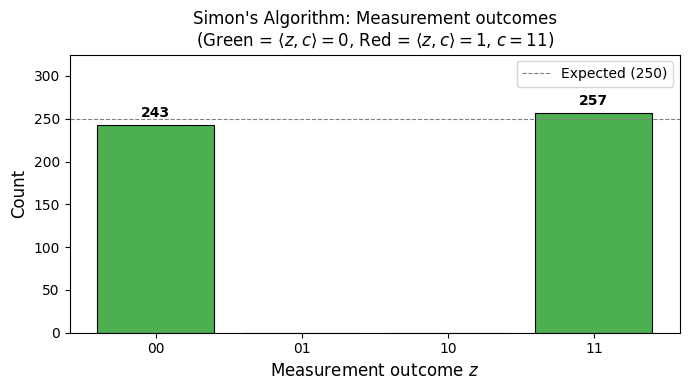

Plot saved to simon_outcomes.png


In [7]:
# ── Bar chart of outcomes ─────────────────────────────────────────────────────
all_bitstrings = ['00', '01', '10', '11']
counts_list = [outcomes.get(tuple(int(b) for b in s), 0) for s in all_bitstrings]

colors = ['#4CAF50' if (int(s[0]) + int(s[1])) % 2 == 0 else '#F44336' for s in all_bitstrings]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(all_bitstrings, counts_list, color=colors, edgecolor='black', linewidth=0.8)

# Annotate bars
for bar, count in zip(bars, counts_list):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(count), ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Measurement outcome $z$', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title("Simon's Algorithm: Measurement outcomes\n"
             r"(Green = $\langle z,c\rangle=0$, Red = $\langle z,c\rangle=1$, $c=11$)",
             fontsize=12)
ax.set_ylim(0, N_SHOTS * 0.65)
ax.axhline(N_SHOTS / 2, linestyle='--', color='gray', linewidth=0.8, label='Expected (250)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('simon_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to simon_outcomes.png")

## 11. Complexity Summary

| | Classical | Simon's Quantum |
|---|---|---|
| **Oracle queries** | $O(2^{n/2})$ expected, $2^{n-1}+1$ worst case | $O(n)$ |
| **Classical post-processing** | — | $O(n^3)$ (Gaussian elimination) |
| **Total** | **Exponential** in $n$ | **Polynomial** in $n$ |

Simon's algorithm achieves an **exponential quantum speedup** — one of the first proven separations between quantum and classical query complexity.

> 🔗 **Connection to Shor's algorithm:** Simon's algorithm is a direct conceptual predecessor to Shor's algorithm for integer factorisation. Both use quantum Fourier-like transforms to extract hidden periodicity from a function. Shor's algorithm is essentially a "continuous" version of Simon's.

## 12. Full Algorithm Summary

```
Simon's Algorithm
═════════════════

Input:  Black-box oracle U_f for f : {0,1}^n → {0,1}^n with hidden period c
Output: The secret string c

Repeat until n linearly independent equations are found:
  ┌──────────────────────────────────────────────────────────┐
  │  QUANTUM PART                                            │
  │  1. Initialise: |0⟩^n ⊗ |0⟩^n                          │
  │  2. Apply H^⊗n to top register                          │
  │  3. Apply oracle U_f  (|x,y⟩ → |x, y⊕f(x)⟩)           │
  │  4. Apply H^⊗n to top register                          │
  │  5. Measure top register → get z with z·c = 0 (mod 2)   │
  └──────────────────────────────────────────────────────────┘
  
  CLASSICAL PART
  6. Store z if it is linearly independent of previous z's

7. Solve the n×n linear system over GF(2) using Gaussian elimination
8. Recover c (choosing c ≠ 0^n if f is two-to-one)
```

## 13. Exercises

Work through these to solidify your understanding.

---

**Exercise 1 — New oracle, n = 2**  
Define a new 2-bit function with hidden period $c = 01$:
- $f(00) = f(01) = \ldots$, $f(10) = f(11) = \ldots$ (choose valid outputs)

Build the oracle matrix, run the circuit 300 times, and verify that only $z \in \{00, 01\}$ appear.

---

**Exercise 2 — One-to-one case (c = 0)**  
What happens when $c = 00$ (i.e., $f$ is one-to-one)?  
- Which values of $z$ should appear after measurement?  
- Construct an injective $f$ for $n = 2$, build the oracle, run the circuit, and confirm your prediction.

---

**Exercise 3 — Interference by hand**  
For $n = 2$ and $c = 01$, manually compute the coefficient of $|z = 01\rangle$ in $|\phi_3\rangle$ using the formula:
$$\text{amplitude of }|z\rangle \propto 1 + (-1)^{\langle z, c \rangle}$$
What is the coefficient?  Is this $z$ observable?


**Exercise 4 — Classical simulation limit**  
The oracle matrix has size $4^n \times 4^n$. Fill in the table:

| $n$ | Qubits | Oracle matrix size | Matrix entries |
|-----|--------|-------------------|----------------|
| 2 | 4 | 16×16 | 256 |
| 3 | 6 | ? | ? |
| 5 | 10 | ? | ? |
| 10 | 20 | ? | ? |
| 20 | 40 | ? | ? |

At what $n$ does classical simulation become infeasible on a modern laptop (assuming 8 GB RAM)?

---

**Exercise 6 — Connection to Deutsch-Jozsa**  
Simon's algorithm and the Deutsch-Jozsa algorithm both use the same circuit skeleton (H – Oracle – H – Measure). Describe the key difference in what the oracle encodes and what question is being answered.

In [ ]:
# ── Workspace for Exercises ───────────────────────────────────────────────────
# Students: use this cell to work on the exercises above.

# Example scaffold for Exercise 1:

# f_ex1 = {
#     (0, 0): (...),   (0, 1): (...),   # f(00) = f(01) = ??
#     (1, 0): (...),   (1, 1): (...),   # f(10) = f(11) = ??
# }
# oracle_ex1 = build_oracle_matrix(n=2, f=f_ex1)
# circuit_ex1 = simon_circuit(n=2, oracle_matrix=oracle_ex1)
# result_ex1  = simulator.run(circuit_ex1, repetitions=300)
# ...

pass

## 14. Key Takeaways

1. **Simon's problem** asks for the hidden XOR period of a two-to-one function — exponentially hard classically, polynomial with quantum computing.

2. **Quantum interference** is the engine of the speedup: the second Hadamard layer causes destructive interference for any $z$ with $\langle z, c \rangle = 1$, so only valid solutions survive measurement.

3. **The oracle** encodes $f$ as a unitary permutation matrix. Designing oracles carefully is a key skill in quantum algorithm development.

4. **Classical post-processing** is essential — the quantum part produces equations, and Gaussian elimination over $GF(2)$ extracts $c$. This hybrid (quantum + classical) structure is common in quantum algorithms.

5. **Historical significance:** Simon's 1994 result directly inspired Shor's 1994 factoring algorithm, one of the most practically impactful quantum algorithms known.

---

*Further reading:*  
- D. Simon, "On the Power of Quantum Computation," SIAM J. Comput., 1997  
- Nielsen & Chuang, *Quantum Computation and Quantum Information*, Chapter 1  
- Yanofsky & Mannucci, *Quantum Computing for Computer Scientists* (source of the textbook examples in this notebook)